#Tasks 

Accuracy: 1.0


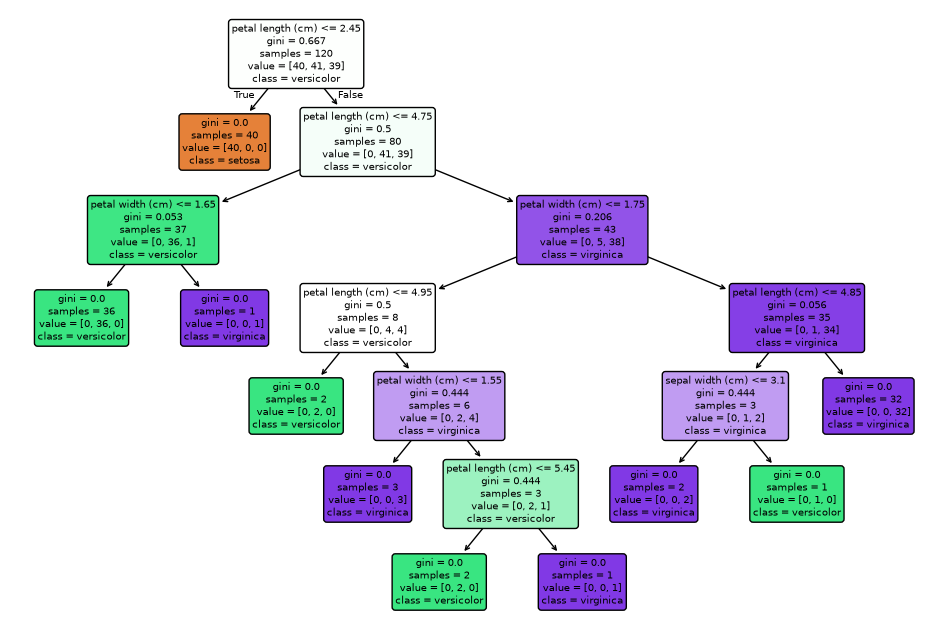

In [1]:
#task 1 
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Decision Tree
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Accuracy
accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

# Visualize Tree
plt.figure(figsize=(12, 8))
plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)

plt.show()

In [2]:
#task 2 
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Different max_depth values
depths = [1, 2, 3, 4, 5, None]

for depth in depths:
    
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"max_depth = {depth}, Accuracy = {accuracy:.4f}")

max_depth = 1, Accuracy = 0.6333
max_depth = 2, Accuracy = 0.9667
max_depth = 3, Accuracy = 1.0000
max_depth = 4, Accuracy = 1.0000
max_depth = 5, Accuracy = 1.0000
max_depth = None, Accuracy = 1.0000


In [4]:
#task 3 
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Load the Titanic dataset
df = sns.load_dataset('titanic')

# 2. Complete Preprocessing Pipeline
# Handle missing numerical features with median
df['age'] = df['age'].fillna(df['age'].median())
df['fare'] = df['fare'].fillna(df['fare'].median())

# Handle missing categorical features with mode
mode_embarked = df['embarked'].mode()[0]
df['embarked'] = df['embarked'].fillna(mode_embarked)

# Encode text categories into integers
le_sex = LabelEncoder()
le_embarked = LabelEncoder()
df['sex_encoded'] = le_sex.fit_transform(df['sex'])
df['embarked_encoded'] = le_embarked.fit_transform(df['embarked'])

# Standardize numerical ranges
scaler = StandardScaler()
df[['age_scaled', 'fare_scaled']] = scaler.fit_transform(df[['age', 'fare']])

# 3. Define Predictor Features (X) and Survival Target (y)
feature_cols = ['pclass', 'sex_encoded', 'embarked_encoded', 'age_scaled', 'fare_scaled']
X = df[feature_cols]
y = df['survived']

# 4. Partition the data using an 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 5. Initialize and Train the Random Forest Classifier
# We instantiate 100 trees and limit max_depth to keep the ensemble generalized
rf_titanic = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_titanic.fit(X_train, y_train)

# 6. Evaluate Model Predictions
y_pred = rf_titanic.predict(X_test)

print("--- Titanic Random Forest Performance ---")
print(f"Test Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Perished', 'Survived']))


--- Titanic Random Forest Performance ---
Test Accuracy Score: 81.56%

--- Confusion Matrix ---
[[96  9]
 [24 50]]

--- Detailed Classification Report ---
              precision    recall  f1-score   support

    Perished       0.80      0.91      0.85       105
    Survived       0.85      0.68      0.75        74

    accuracy                           0.82       179
   macro avg       0.82      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



--- Ordered Feature Importances ---
         Feature  Importance
       GrLivArea    0.643761
      GarageCars    0.087285
     LotFrontage    0.081031
  KitchenQual_TA    0.031798
  KitchenQual_Gd    0.030761
     MSZoning_RL    0.030249
     MSZoning_RM    0.028138
  KitchenQual_Ex    0.020380
MSZoning_C (all)    0.020247
  KitchenQual_Fa    0.019656
    MSZoning_nan    0.006695


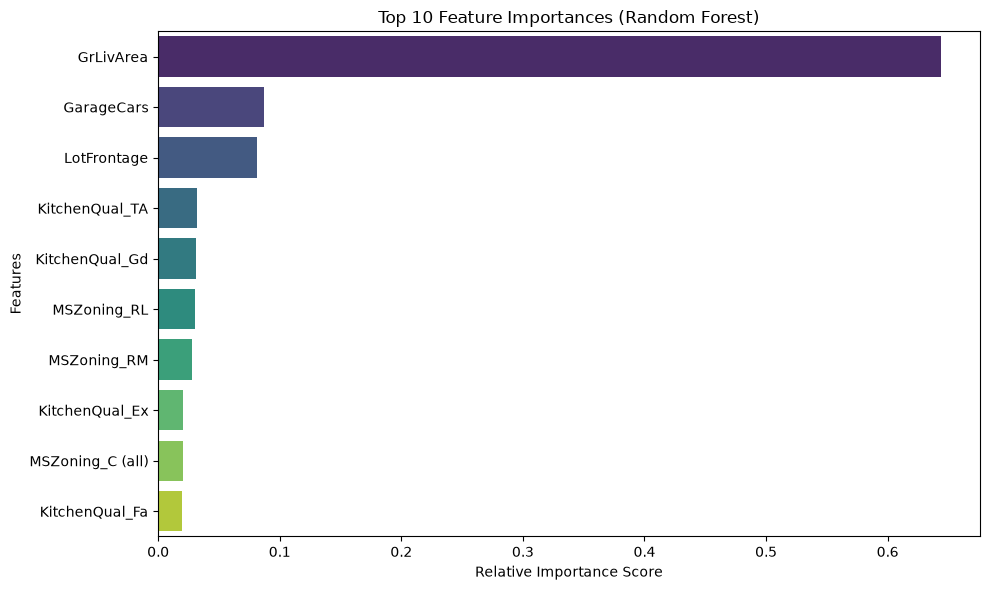

In [1]:
#task 4 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

# 1. Recreate the pipeline dataset (10 features total)
np.random.seed(42)
n_samples = 1000
data = {
    'LotFrontage': np.random.choice(
        [60.0, 70.0, 80.0, np.nan], size=n_samples, p=[0.4, 0.3, 0.2, 0.1]
    ),
    'GrLivArea': np.random.randint(800, 3500, size=n_samples),
    'GarageCars': np.random.choice(
        [1.0, 2.0, 3.0, np.nan], size=n_samples, p=[0.3, 0.5, 0.18, 0.02]
    ),
    'MSZoning': np.random.choice(
        ['RL', 'RM', 'C (all)', np.nan], size=n_samples, p=[0.7, 0.2, 0.08, 0.02]
    ),
    'KitchenQual': np.random.choice(
        ['Gd', 'TA', 'Ex', 'Fa'], size=n_samples, p=[0.4, 0.4, 0.1, 0.1]
    ),
    'SalePrice': np.random.randint(100000, 400000, size=n_samples),
}
df = pd.DataFrame(data)

# Clean missing entries
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())
df['GarageCars'] = df['GarageCars'].fillna(df['GarageCars'].median())
df['MSZoning'] = df['MSZoning'].fillna(df['MSZoning'].mode()[0])

# One-hot encode categorical features
df_encoded = pd.get_dummies(df, columns=['MSZoning', 'KitchenQual'])

# Split into Features (X) and Target (y)
X = df_encoded.drop(columns=['SalePrice'])
y = df_encoded['SalePrice']

# 2. Fit a Random Forest Regressor to extract importances
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# 3. Extract and sort feature importances
importance_df = pd.DataFrame(
    {'Feature': X.columns, 'Importance': rf.feature_importances_}
).sort_values(by='Importance', ascending=False)

print("--- Ordered Feature Importances ---")
print(importance_df.to_string(index=False))

# 4. Plot the Top 10 Feature Importances as a horizontal bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df.head(10),
    palette='viridis',
    hue='Feature',
    legend=False,
)

plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Relative Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


#Practice Sheet

In [2]:
#practice sheet 1
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

# 1. Create a simulated Loan Dataset
np.random.seed(42)
n_samples = 600

data = {
    'ApplicantIncome': np.random.randint(2000, 10000, size=n_samples),
    'CreditScore': np.random.randint(500, 850, size=n_samples),
    'LoanAmount': np.random.randint(50, 500, size=n_samples),
    'Education': np.random.choice(
        ['Graduate', 'Not Graduate'], size=n_samples, p=[0.75, 0.25]
    ),
    'MaritalStatus': np.random.choice(
        ['Married', 'Single'], size=n_samples, p=[0.6, 0.4]
    ),
}
df = pd.DataFrame(data)

# Generate a logical target variable 'Loan_Status' (1 = Approved, 0 = Rejected)
# Rules: Highly dependent on Credit Score and reasonably dependent on Income
df['Loan_Status'] = np.where(
    (df['CreditScore'] > 650) & (df['ApplicantIncome'] > 3500), 1, 0
)
# Add some random noise to simulate real-world variance
noise = np.random.choice([0, 1], size=n_samples, p=[0.9, 0.1])
df['Loan_Status'] = np.where(noise == 1, 1 - df['Loan_Status'], df['Loan_Status'])

# 2. Preprocess Categorical Columns
le = LabelEncoder()
df['Education'] = le.fit_transform(df['Education'])
df['MaritalStatus'] = le.fit_transform(df['MaritalStatus'])

# 3. Split into Features (X) and Target (y)
X = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 4. Initialize and Train the Decision Tree Classifier
# We set max_depth=4 to prevent the tree from overfitting the training data
clf = DecisionTreeClassifier(
    criterion='gini', max_depth=4, random_state=42
)
clf.fit(X_train, y_train)

# 5. Make Predictions
y_pred = clf.predict(X_test)

# 6. Evaluate Performance
print("--- Model Accuracy ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Approved']))


--- Model Accuracy ---
Accuracy Score: 85.83%

--- Confusion Matrix ---
[[66  7]
 [10 37]]

--- Classification Report ---
              precision    recall  f1-score   support

    Rejected       0.87      0.90      0.89        73
    Approved       0.84      0.79      0.81        47

    accuracy                           0.86       120
   macro avg       0.85      0.85      0.85       120
weighted avg       0.86      0.86      0.86       120



In [3]:
#practice sheet 2
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

# 1. Replicate the baseline Loan Dataset
np.random.seed(42)
n_samples = 600

data = {
    'ApplicantIncome': np.random.randint(2000, 10000, size=n_samples),
    'CreditScore': np.random.randint(500, 850, size=n_samples),
    'LoanAmount': np.random.randint(50, 500, size=n_samples),
    'Education': np.random.choice(
        ['Graduate', 'Not Graduate'], size=n_samples, p=[0.75, 0.25]
    ),
    'MaritalStatus': np.random.choice(
        ['Married', 'Single'], size=n_samples, p=[0.6, 0.4]
    ),
}
df = pd.DataFrame(data)

# Generate target variable
df['Loan_Status'] = np.where(
    (df['CreditScore'] > 650) & (df['ApplicantIncome'] > 3500), 1, 0
)
noise = np.random.choice([0, 1], size=n_samples, p=[0.9, 0.1])
df['Loan_Status'] = np.where(noise == 1, 1 - df['Loan_Status'], df['Loan_Status'])

# Preprocess categorical features
le = LabelEncoder()
df['Education'] = le.fit_transform(df['Education'])
df['MaritalStatus'] = le.fit_transform(df['MaritalStatus'])

# Features & Target Split
X = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 2. Train Single Decision Tree Classifier
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

# 3. Train Random Forest Classifier
# n_estimators=100 trains 100 independent decision trees simultaneously
rf_model = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

# 4. Comparative Output
print("--- Accuracy Breakdown ---")
print(f"Single Decision Tree Accuracy : {dt_acc * 100:.2f}%")
print(f"Random Forest Ensemble Accuracy: {rf_acc * 100:.2f}%")
print(f"Net Accuracy Gain               : {(rf_acc - dt_acc) * 100:+.2f}%")

print("\n--- Random Forest Classification Report ---")
print(classification_report(y_test, rf_pred, target_names=['Rejected', 'Approved']))


--- Accuracy Breakdown ---
Single Decision Tree Accuracy : 85.83%
Random Forest Ensemble Accuracy: 89.17%
Net Accuracy Gain               : +3.33%

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

    Rejected       0.88      0.95      0.91        73
    Approved       0.90      0.81      0.85        47

    accuracy                           0.89       120
   macro avg       0.89      0.88      0.88       120
weighted avg       0.89      0.89      0.89       120

